In [8]:
import folium
from eo_tides import tag_tides,tide_stats
from pystac.client import Client
from odc.stac import load
from shapely.geometry import box

In [2]:
tide_dir=r"D:\tide_models"
model="EOT20"

In [3]:
# Set up a bbox over bali
bbox = [115.00, -8.10, 115.10, -8.00]
minx, miny, maxx, maxy = bbox

# Center the map on the bbox
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

m = folium.Map(location=[center_lat, center_lon], zoom_start=11)

# Draw the bounding box
folium.Rectangle(
    bounds=[[miny, minx], [maxy, maxx]],  # folium uses [[lat, lon], [lat, lon]]
    color="red",
    fill=True,
    fill_color="red",
    fill_opacity=0.1,
    weight=2,
).add_to(m)

m

In [4]:
# Set up a bbox over bali
bbox = [115.00, -8.10, 115.10, -8.00]

# STAC catalog and collection
catalog = "https://earth-search.aws.element84.com/v1/"
client = Client.open(catalog)
collection = "sentinel-2-l2a"

# Search for items
items = client.search(
    collections=[collection],
    bbox=bbox,
    datetime="2025-01-01/2025-02-01",
).item_collection()

print(f"Found {len(items)} items in {collection} for bbox {bbox}")

Found 13 items in sentinel-2-l2a for bbox [115.0, -8.1, 115.1, -8.0]


In [5]:
# Lazy load the Sentinel-2 items. No actual data is fetched.
ds = load(items, bbox=bbox, measurements=["red", "green", "blue"], groupby="solar_day", chunks={})
ds

<xarray.Dataset> Size: 96MB
Dimensions:      (y: 1112, x: 1109, time: 13)
Coordinates:
  * y            (y) float64 9kB 9.115e+06 9.115e+06 ... 9.104e+06 9.104e+06
  * x            (x) float64 9kB 2.796e+05 2.796e+05 ... 2.906e+05 2.906e+05
  * time         (time) datetime64[us] 104B 2025-01-01T02:40:02.278000 ... 20...
    spatial_ref  int32 4B 32750
Data variables:
    red          (time, y, x) uint16 32MB dask.array<chunksize=(1, 1112, 1109), meta=np.ndarray>
    green        (time, y, x) uint16 32MB dask.array<chunksize=(1, 1112, 1109), meta=np.ndarray>
    blue         (time, y, x) uint16 32MB dask.array<chunksize=(1, 1112, 1109), meta=np.ndarray>

In [6]:
tides_da = tag_tides(
    data=ds,
    model=model,
    directory=tide_dir,
)

ds["tide_height"] = tides_da
ds

Setting tide modelling location from dataset centroid: 115.05, -8.05
Modelling tides with EOT20


<xarray.Dataset> Size: 96MB
Dimensions:      (y: 1112, x: 1109, time: 13)
Coordinates:
  * y            (y) float64 9kB 9.115e+06 9.115e+06 ... 9.104e+06 9.104e+06
  * x            (x) float64 9kB 2.796e+05 2.796e+05 ... 2.906e+05 2.906e+05
  * time         (time) datetime64[ns] 104B 2025-01-01T02:40:02.278000 ... 20...
    spatial_ref  int32 4B 32750
    tide_model   <U5 20B 'EOT20'
Data variables:
    red          (time, y, x) uint16 32MB dask.array<chunksize=(1, 1112, 1109), meta=np.ndarray>
    green        (time, y, x) uint16 32MB dask.array<chunksize=(1, 1112, 1109), meta=np.ndarray>
    blue         (time, y, x) uint16 32MB dask.array<chunksize=(1, 1112, 1109), meta=np.ndarray>
    tide_height  (time) float32 52B -0.342 -0.5553 -0.4685 ... -0.05351 -0.2159

Using tide modelling location: 115.05, -8.05


Modelling tides with EOT20
Using tide modelling location: 115.05, -8.05
Modelling tides with EOT20


🌊 Modelled astronomical tide range: 1.86 m (-0.98 to 0.88 m).
🛰️ Observed tide range: 0.59 m (-0.56 to 0.03 m).

🔴 32% of the modelled astronomical tide range was observed at this location.
🔴 The highest 45% (0.85 m) of the tide range was never observed.
🔴 The lowest 23% (0.43 m) of the tide range was never observed.

🌊 Mean modelled astronomical tide height: 0.00 m.
🛰️ Mean observed tide height: -0.21 m.
⬇️ The mean observed tide height was -0.21 m lower than the mean modelled astronomical tide height.


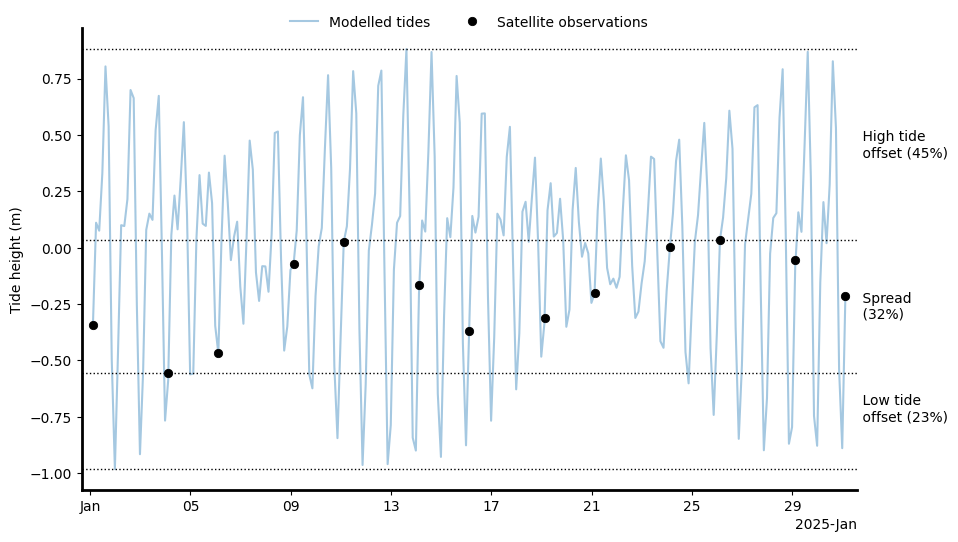

In [9]:
stats = tide_stats(
    data=ds,
    model=model,
    directory=tide_dir,
)